# Import Libraries


> ℹ️ *We install now all the libraries here in the venv.*

In [ ]:
#The following Python packages are installed into the active virtual environment:
!pip install optuna
!pip install catboost
!pip install lightgbm
!pip install missingno optuna xgboost catboost lightgbm eli5


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


> ℹ️ *First, we import the necessary Python libraries.*


In [8]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score
from scipy import stats
import pandas as pd
import numpy as np
import base64,os,random,gc
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno


import matplotlib.pyplot as plotter
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import optuna
import xgboost as xgb
from xgboost import XGBRegressor
import catboost
from catboost import CatBoostRegressor
import lightgbm as lgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn import datasets
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lightgbm import *
pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

import warnings
warnings.filterwarnings('ignore')

# Read Dataset

> ➡️ *Here, we import data from a csv file, with pandas.*



In [9]:
train = pd.read_csv("../external-sources/output_csv/model.csv")
train, test = train_test_split(train, test_size=0.2, random_state=42)
train=train.reset_index(drop=True)
test=test.reset_index(drop=True)
display(train.head())
display(test.head())

,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,109,3,1690,67,342.0,3.0,457.5,2755331.00,1221328.750,2014,10,446.0
1,121,2,3100,33,1335.0,2.0,513.1,2683559.25,1240013.875,1986,11,485.0
2,115,4,2605,183,14054.0,4.0,392.4,2667247.50,1255916.125,2011,8,363.0
3,55,2,1250,25,9693.0,1.0,329.3,2622505.25,1259121.875,1750,8,381.0
4,39,1,790,138,7732.0,2.0,670.6,2746813.50,1254518.750,1987,13,331.0


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,57,2,1890,186,10892.0,3.0,556.9,2539103.75,1152548.250,1933,20,420.0
1,48,2,1440,58,73.0,3.0,517.0,2655301.50,1222483.375,1969,5,409.0
2,70,2,1500,29,126.0,4.0,1356.0,2604730.00,1129117.875,1969,16,297.0
3,94,3,1670,144,3537.0,4.0,299.5,2638795.25,1266197.000,2005,9,267.0
4,84,3,1630,93,4172.0,4.0,545.0,2613913.50,1210679.250,2005,8,292.0


> ➡️ *Now we rename the columns to more suitable names and sort them accordingly.*

In [10]:
new_names = {
    "area_sqm": "area",
    "rooms": "rooms",
    "price_cold": "price",
    "population": "population",
    "oev_score": "oev",
    "solar_class": "solar",
    "elevation_m": "elevation",
    "lv95_east": "east",
    "lv95_north": "north",
    "gbauj": "year_built",
    "ganzwhg": "apartments",
    "garea": "land_area",
}

train = train.rename(columns=new_names)
test = test.rename(columns=new_names)

> ➡️ *After rename:*

In [11]:
display(train.tail())
display(test.tail())

,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area
3623,68,3,1661,32,1058.0,4.0,505.5,2679710.25,1251235.875,1954,6,260.0
3624,97,4,1870,133,4415.0,4.0,533.0,2614712.25,1212489.750,1973,15,351.0
3625,31,1,835,177,6423.0,1.0,667.2,2744574.25,1253861.000,1918,12,158.0
3626,111,4,1770,110,930.0,3.0,403.4,2748842.50,1264033.375,1974,36,441.0
3627,86,3,1400,56,658.0,2.0,485.6,2561968.75,1193881.125,2009,6,240.0


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area
903,54,2,1200,37,297.0,4.0,342.9,2697976.50,1122567.375,1972,2,105.0
904,80,2,2340,79,2017.0,3.0,440.5,2681588.00,1253222.125,1981,6,247.0
905,113,3,1800,17,2174.0,1.0,524.9,2605452.50,1210915.875,1755,8,484.0
906,90,3,1840,81,5234.0,4.0,454.4,2609938.75,1224044.250,2014,8,312.0
907,285,8,3800,41,4362.0,1.0,424.7,2559432.50,1143123.250,1890,1,59.0


> ➡️ *Now we sort it.*

In [12]:
fixed_order = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]
train = train[fixed_order]
test = test[fixed_order]

> ➡️ *Result after sorting.*

In [13]:
display(train.tail())
display(test.tail())

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
3623,2679710.25,1251235.875,505.5,68,3,1954,6,260.0,32,1058.0,4.0,1661
3624,2614712.25,1212489.750,533.0,97,4,1973,15,351.0,133,4415.0,4.0,1870
3625,2744574.25,1253861.000,667.2,31,1,1918,12,158.0,177,6423.0,1.0,835
3626,2748842.50,1264033.375,403.4,111,4,1974,36,441.0,110,930.0,3.0,1770
3627,2561968.75,1193881.125,485.6,86,3,2009,6,240.0,56,658.0,2.0,1400


,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
903,2697976.50,1122567.375,342.9,54,2,1972,2,105.0,37,297.0,4.0,1200
904,2681588.00,1253222.125,440.5,80,2,1981,6,247.0,79,2017.0,3.0,2340
905,2605452.50,1210915.875,524.9,113,3,1755,8,484.0,17,2174.0,1.0,1800
906,2609938.75,1224044.250,454.4,90,3,2014,8,312.0,81,5234.0,4.0,1840
907,2559432.50,1143123.250,424.7,285,8,1890,1,59.0,41,4362.0,1.0,3800


# 3. Exploration Data

> ➡️ *Here, we inspect missing values in both the training and testing datasets and visualize their distribution using heatmaps.*


train


east          0
north         0
elevation     0
area          0
rooms         0
year_built    0
apartments    0
land_area     0
population    0
oev           0
solar         0
price         0
dtype: int64

test


east          0
north         0
elevation     0
area          0
rooms         0
year_built    0
apartments    0
land_area     0
population    0
oev           0
solar         0
price         0
dtype: int64

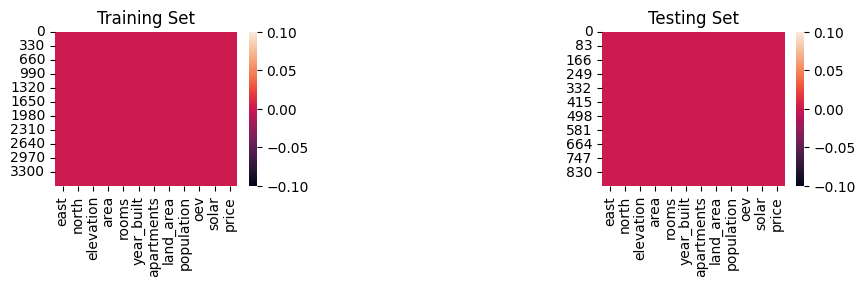

In [14]:
print('train')
display(train.isnull().sum())
print('test')
display(test.isnull().sum())

plt.figure(figsize = (10, 2))

plt.subplot(1, 3, 1)
plt.title("Training Set")
sns.heatmap(train.isnull())

plt.subplot(1, 3, 3)
plt.title("Testing Set")
sns.heatmap(test.isnull())
plt.show()

> ➡️ *Here, we visualize missing values in the training dataset using the missingno matrix plot.*

<Axes: >

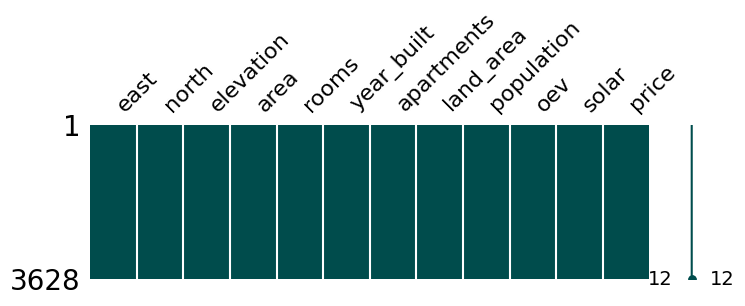

In [15]:
msno.matrix(df=train, figsize=(8,2), color=(0,.3,.3))

<Axes: >

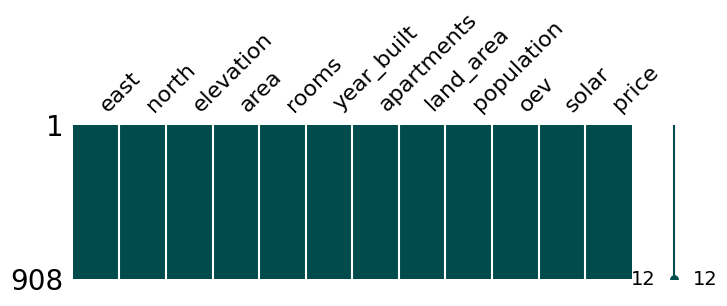

In [16]:
msno.matrix(df=test, figsize=(8,2), color=(0,.3,.3))


In [17]:
print('train')
display(train.info())
print('test')
display(test.info())

train
<class 'pandas.DataFrame'>
RangeIndex: 3628 entries, 0 to 3627
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   east        3628 non-null   float64
 1   north       3628 non-null   float64
 2   elevation   3628 non-null   float64
 3   area        3628 non-null   int64  
 4   rooms       3628 non-null   int64  
 5   year_built  3628 non-null   int64  
 6   apartments  3628 non-null   int64  
 7   land_area   3628 non-null   float64
 8   population  3628 non-null   int64  
 9   oev         3628 non-null   float64
 10  solar       3628 non-null   float64
 11  price       3628 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 340.3 KB


None

test
<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   east        908 non-null    float64
 1   north       908 non-null    float64
 2   elevation   908 non-null    float64
 3   area        908 non-null    int64  
 4   rooms       908 non-null    int64  
 5   year_built  908 non-null    int64  
 6   apartments  908 non-null    int64  
 7   land_area   908 non-null    float64
 8   population  908 non-null    int64  
 9   oev         908 non-null    float64
 10  solar       908 non-null    float64
 11  price       908 non-null    int64  
dtypes: float64(6), int64(6)
memory usage: 85.3 KB


None

> ➡️ *Here, we merge the training and test datasets into a single DataFrame to perform consistent preprocessing and feature engineering across both sets.*


In [18]:
df = pd.concat([train, test], ignore_index=True)
df

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
0,2755331.00,1221328.750,457.5,109,3,2014,10,446.0,67,342.0,3.0,1690
1,2683559.25,1240013.875,513.1,121,2,1986,11,485.0,33,1335.0,2.0,3100
2,2667247.50,1255916.125,392.4,115,4,2011,8,363.0,183,14054.0,4.0,2605
3,2622505.25,1259121.875,329.3,55,2,1750,8,381.0,25,9693.0,1.0,1250
4,2746813.50,1254518.750,670.6,39,1,1987,13,331.0,138,7732.0,2.0,790
...,...,...,...,...,...,...,...,...,...,...,...,...
4531,2697976.50,1122567.375,342.9,54,2,1972,2,105.0,37,297.0,4.0,1200
4532,2681588.00,1253222.125,440.5,80,2,1981,6,247.0,79,2017.0,3.0,2340
4533,2605452.50,1210915.875,524.9,113,3,1755,8,484.0,17,2174.0,1.0,1800
4534,2609938.75,1224044.250,454.4,90,3,2014,8,312.0,81,5234.0,4.0,1840


## 3.1. Univariate Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Einheitliches Theme
plt.style.use('seaborn-v0_8')

# Globale rcParams
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'grid.color': '#DDDDDD',
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'legend.frameon': False,
    'axes.titlepad': 12,
})

# Einheitliche Farbpalette
sns.set_palette("crest")


In [66]:
COLOR_PRIMARY = "crest"     # Blau


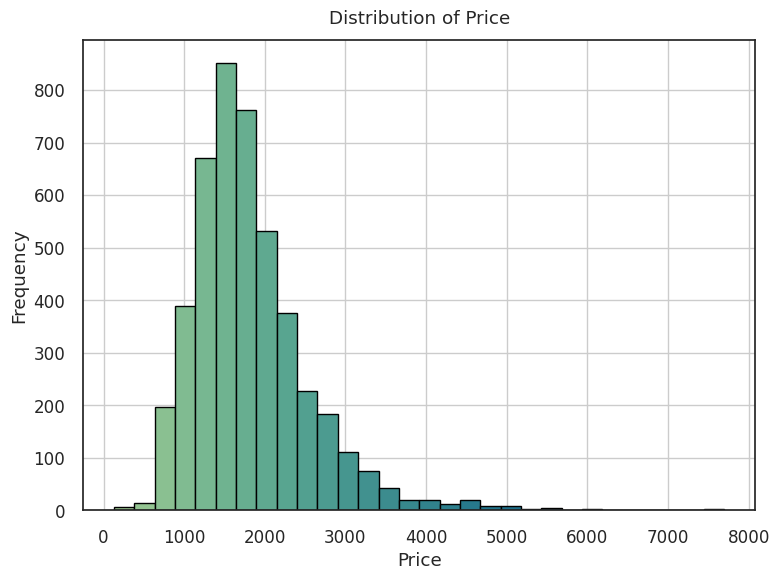

In [67]:
import numpy as np

values = df['price'].dropna()
counts, bins = np.histogram(values, bins=30)

colors = sns.color_palette(COLOR_PRIMARY, len(counts))

plt.figure(figsize=(8, 6))
for i in range(len(counts)):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i+1] - bins[i],
        color=colors[i],
        edgecolor="black",
        align="edge"
    )

plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


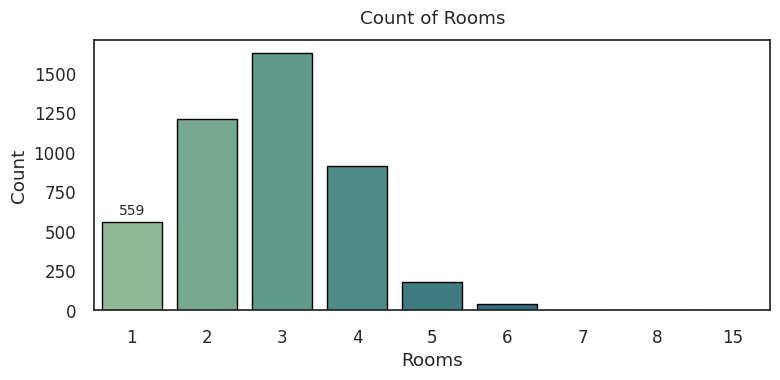

In [68]:
bedrooms_count = df['rooms'].value_counts().sort_index()

colors = sns.color_palette(COLOR_PRIMARY, len(bedrooms_count))

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    x=bedrooms_count.index,
    y=bedrooms_count.values,
    palette=colors,
    edgecolor="black"
)

ax.bar_label(ax.containers[0], fontsize=10, padding=3)

plt.title('Count of Rooms')
plt.xlabel('Rooms')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


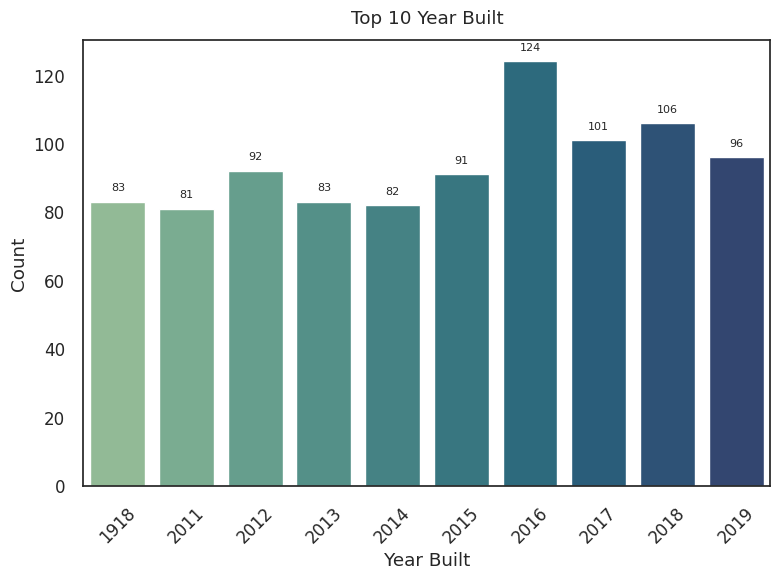

In [69]:
top_year_built = df['year_built'].value_counts().nlargest(10)

plt.figure(figsize=(8,6))
ax = sns.barplot(x=top_year_built.index, y=top_year_built.values, palette=COLOR_PRIMARY)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=8)
plt.title('Top 10 Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.2. Bivariate Analysis


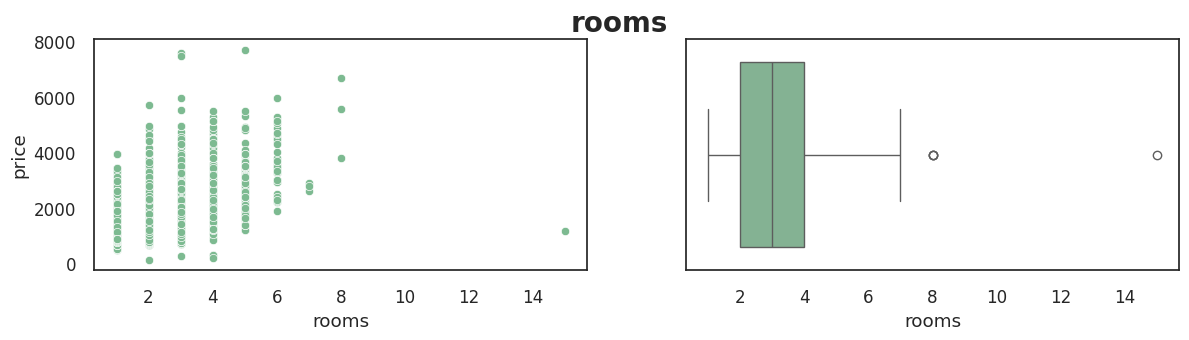

In [96]:
x = 'rooms'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

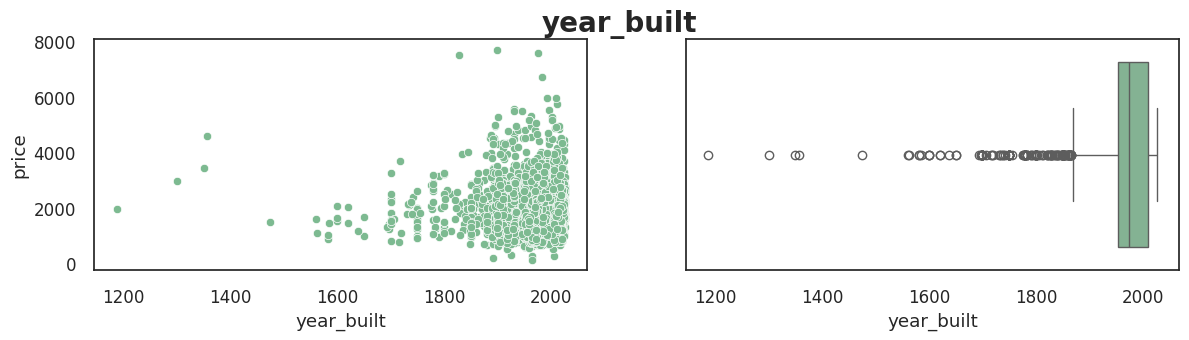

In [95]:
x = 'year_built'
sns.set_palette(COLOR_PRIMARY)

fig = plt.figure(figsize=(14, 3))
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

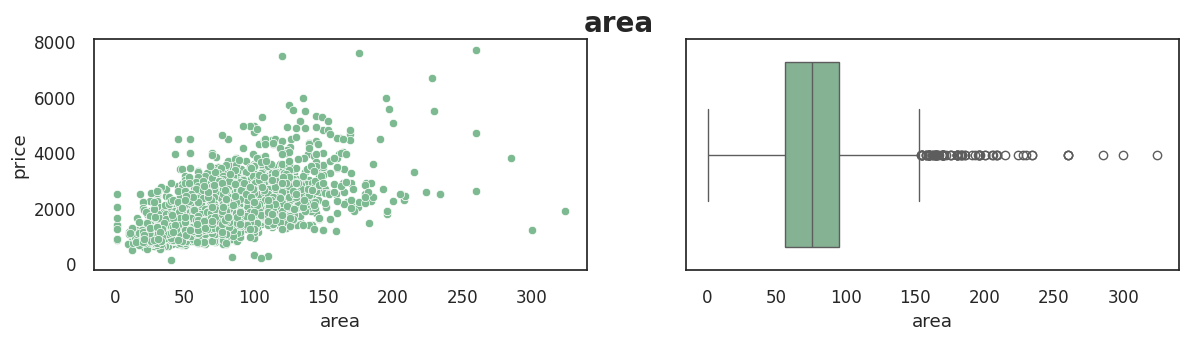

In [93]:
x = 'area'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

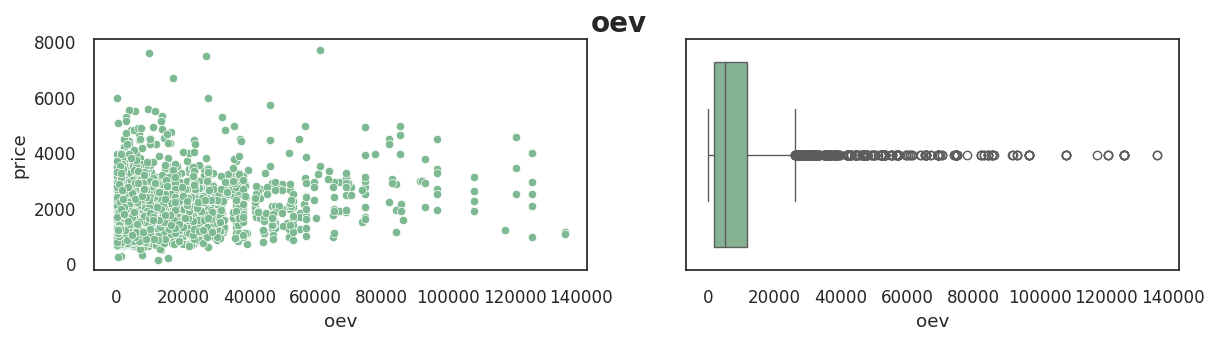

In [97]:
x = 'oev'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

## 3.4. Corelation Heatmap

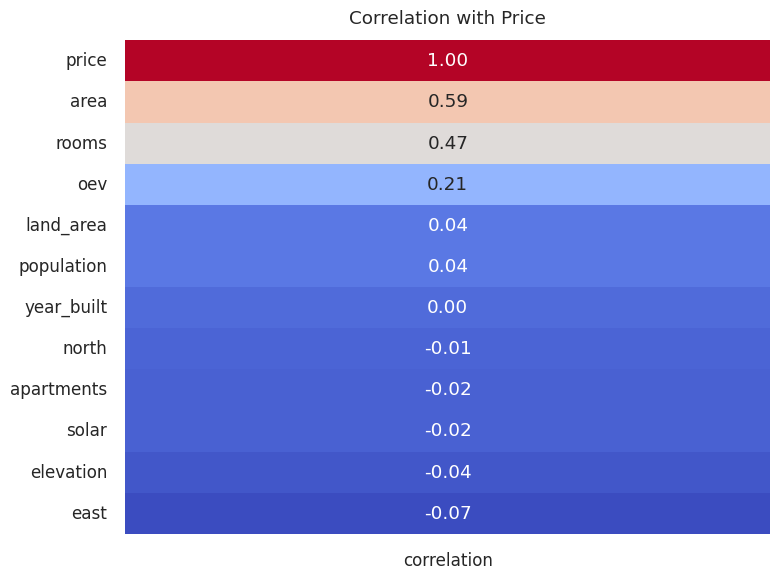

In [111]:
selected_columns = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]

target_corr = df[selected_columns].corrwith(df["price"])

# höchste Korrelation oben
target_corr = target_corr.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.1)
sns.set_style("white")
sns.set_palette("PuBuGn_d")

sns.heatmap(
    target_corr.to_frame(name="correlation"),
    cmap="coolwarm",      # <-- Farbanpassung
    annot=True,
    fmt=".2f",
    cbar=False
)

plt.title("Correlation with Price")
plt.tight_layout()
plt.show()


# Extract Training Feature Names

> ➡️ *Here, we extract the list of feature column names from the training dataset by removing the target variable to ensure consistent alignment with the model inputs.*


In [29]:
train_feature = train.columns.drop('price').tolist()
train_feature

['east',
 'north',
 'elevation',
 'area',
 'rooms',
 'year_built',
 'apartments',
 'land_area',
 'population',
 'oev',
 'solar']

> ➡️ *Here, we generate a descriptive statistics table for the training features and enhance it with visual styling to highlight mean values, standard deviations, and median distributions.*

In [30]:
train[train_feature].describe().T\
        .style.bar(subset=['mean'], color=px.colors.qualitative.G10[0])\
        .background_gradient(subset=['std'], cmap='BuPu')\
        .background_gradient(subset=['50%'], cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
east,3628.000000,2641929.897602,69043.537944,2494649.250000,2598280.250000,2648399.625000,2691052.750000,2818550.000000
north,3628.000000,1219130.985047,51706.015766,1076962.000000,1181087.906250,1244662.000000,1258351.875000,1286728.500000
elevation,3628.000000,462.910254,159.629245,197.700000,391.875000,435.400000,521.450000,1566.900000
area,3628.000000,77.317530,32.044454,1.000000,55.000000,76.000000,96.000000,324.000000
rooms,3628.000000,2.785281,1.108870,1.000000,2.000000,3.000000,3.000000,15.000000
year_built,3628.000000,1968.946803,56.783062,1187.000000,1953.000000,1975.000000,2010.000000,2026.000000
apartments,3628.000000,15.661246,21.068957,1.000000,6.000000,10.000000,18.000000,317.000000
land_area,3628.000000,401.372106,531.481568,27.000000,196.000000,279.000000,418.000000,13020.000000
population,3628.000000,108.331588,81.650675,3.000000,49.000000,90.000000,143.000000,602.000000
oev,3628.000000,9908.989526,14957.552698,0.000000,1821.750000,4951.500000,11216.000000,135157.000000


# Train–Test Feature Distribution Comparison

> ➡️ *Here, we compare the feature distributions between the training and test datasets by plotting side‑by‑side histograms for each variable.*


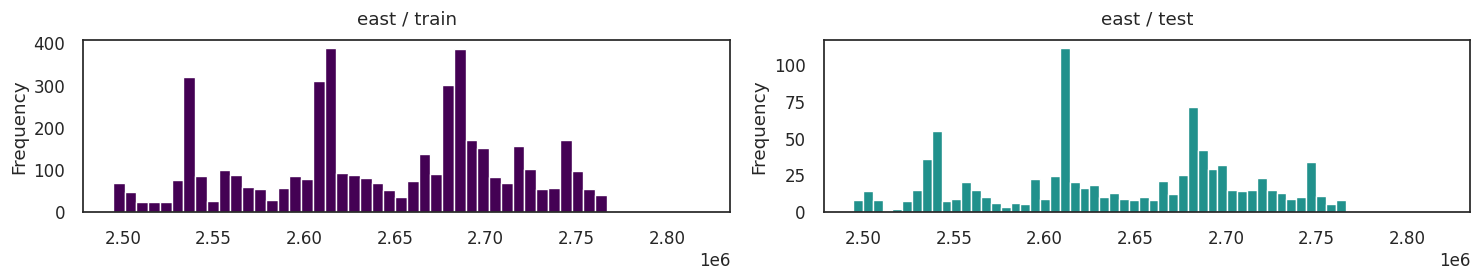

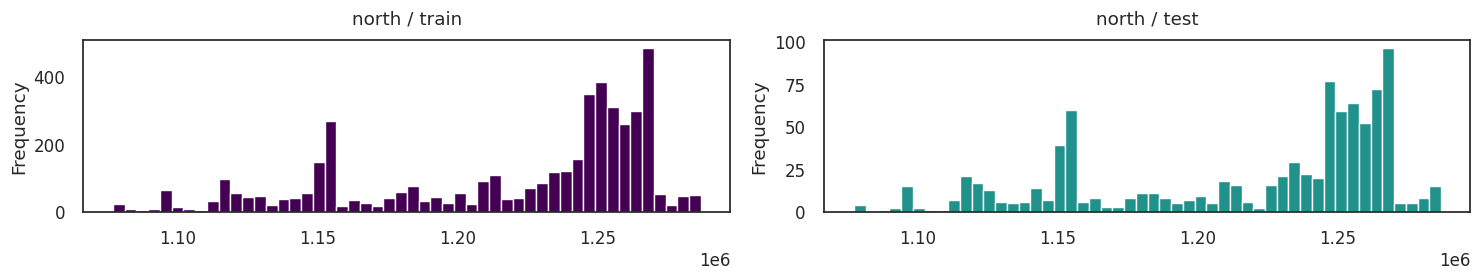

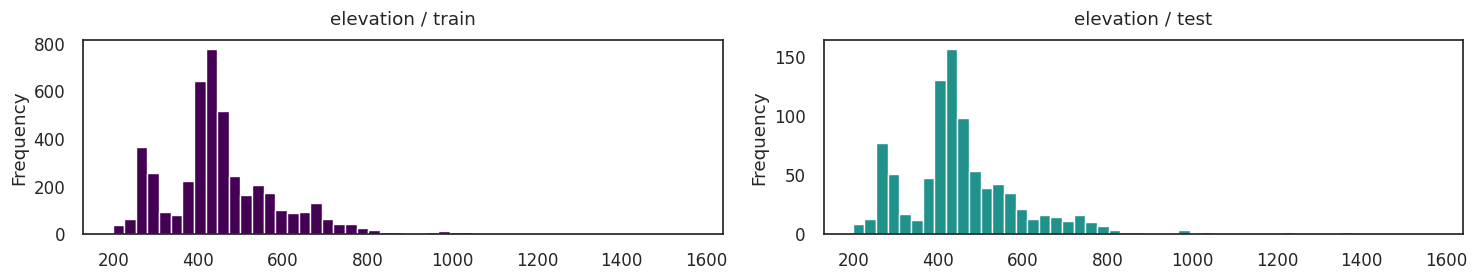

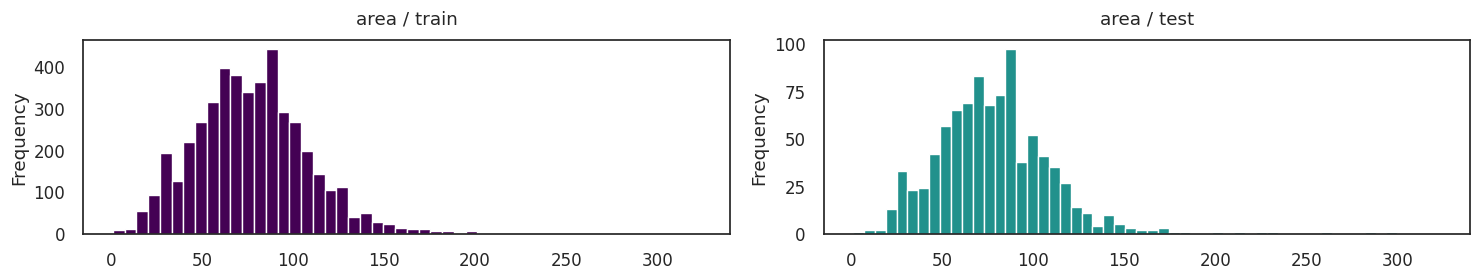

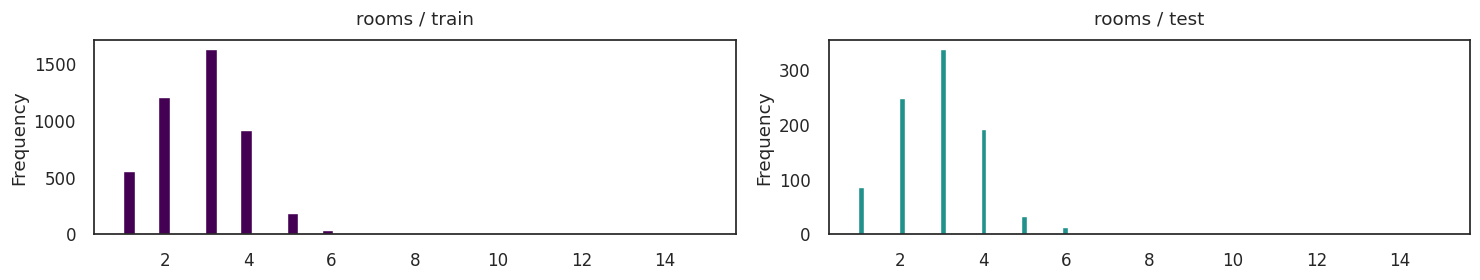

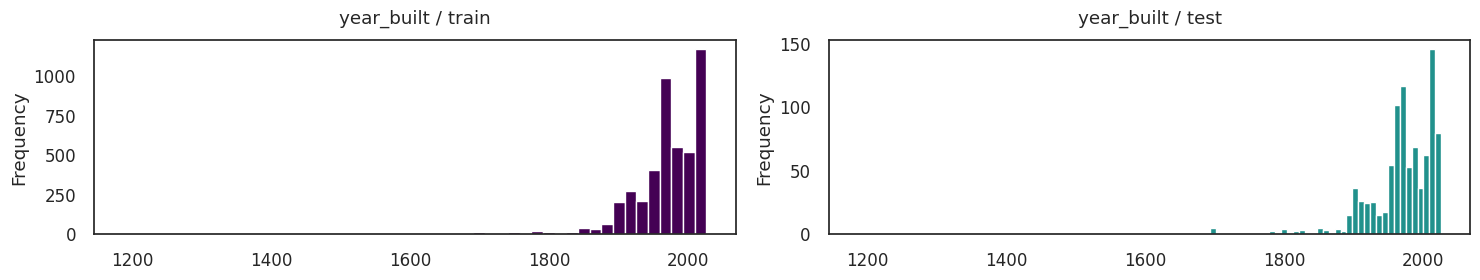

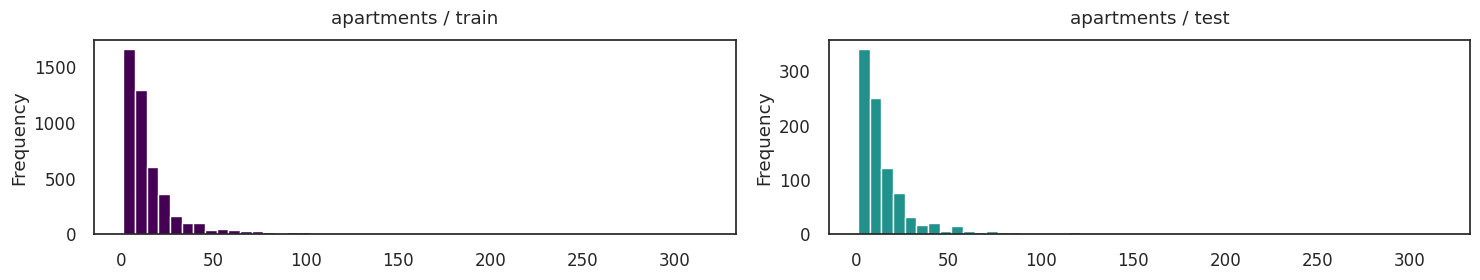

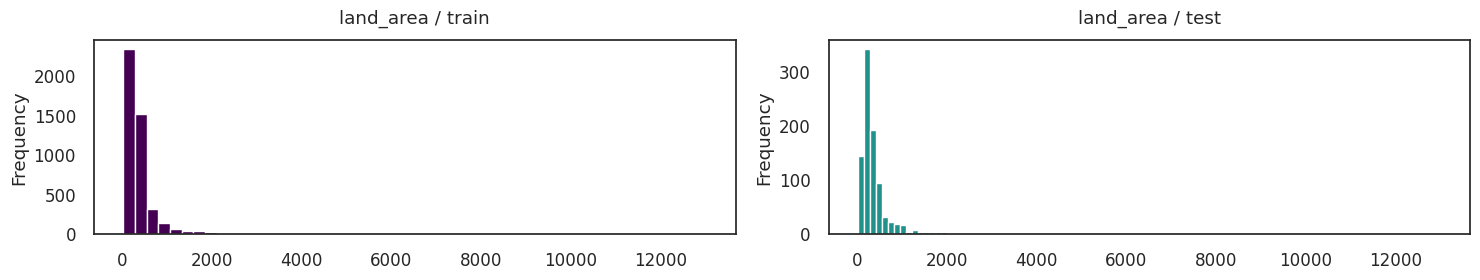

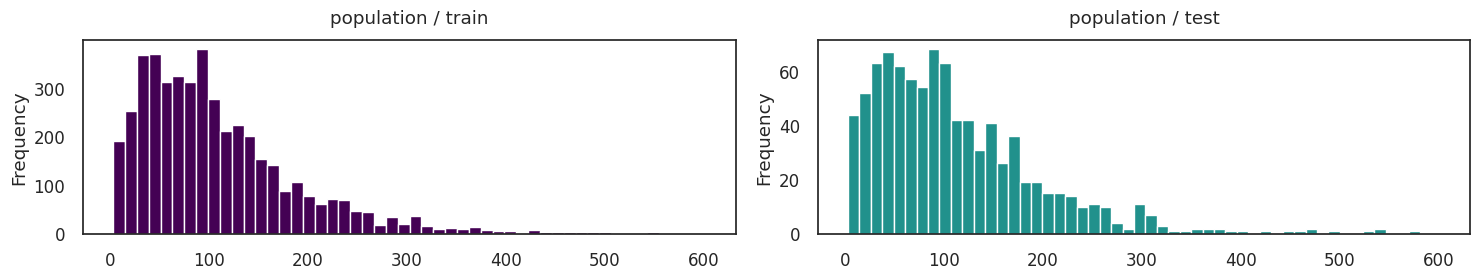

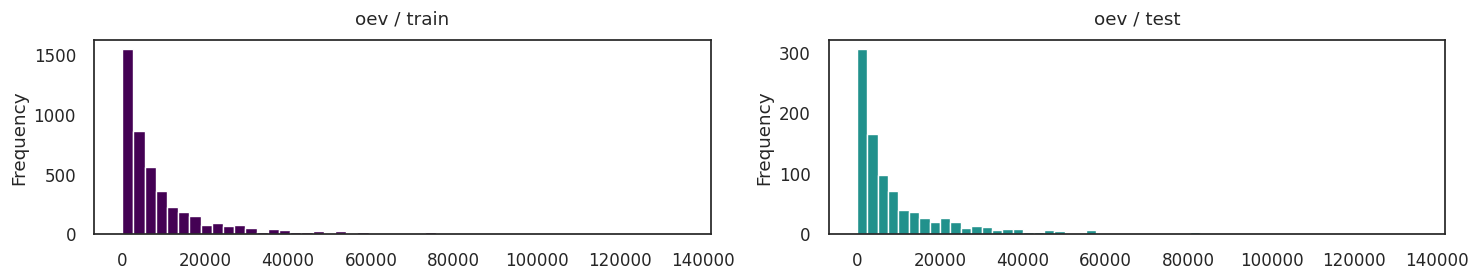

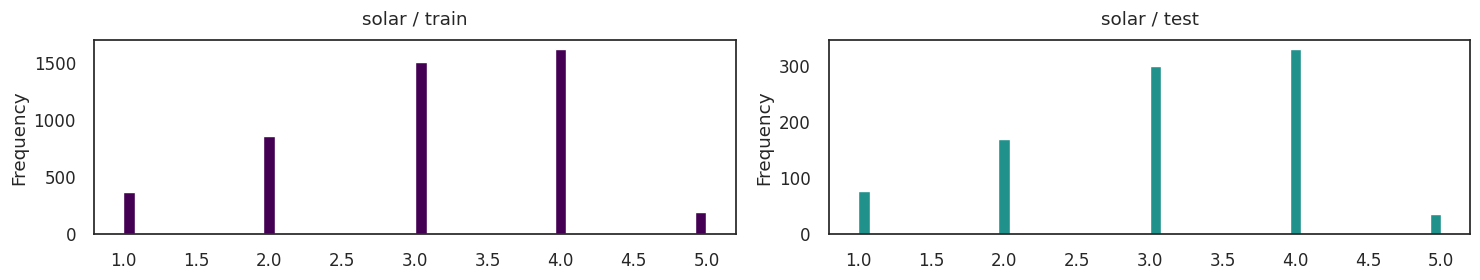

In [103]:
for feat in train_feature:
    plt.figure(figsize=(15, 3))

    ax1 = plt.subplot(1, 2, 1)
    train[feat].plot(
        kind='hist',
        bins=50,
        color="#440154"   # dunkles viridis
    )
    plt.title(feat + ' / train')

    ax2 = plt.subplot(1, 2, 2, sharex=ax1)
    test[feat].plot(
        kind='hist',
        bins=50,
        color="#21918c"   # helleres viridis
    )
    plt.title(feat + ' / test')

    plt.tight_layout()
    plt.show()


# Skewness and Kurtosis Analysis

> ➡️ *Here, we compute skewness and kurtosis for selected numerical features to assess distribution shape and detect potential asymmetry or heavy tails.*


In [32]:
columns = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]

for col in columns:
    print(f"Skewness {col}: {df[col].skew():.6f}")
    print(f"Kurtosis {col}: {df[col].kurt():.6f}")
    print()

Skewness east: -0.216149
Kurtosis east: -0.956489

Skewness north: -0.899207
Kurtosis north: -0.490834

Skewness elevation: 2.085127
Kurtosis elevation: 8.489730

Skewness area: 0.892136
Kurtosis area: 3.101460

Skewness rooms: 0.544438
Kurtosis rooms: 3.228168

Skewness year_built: -3.659907
Kurtosis year_built: 28.281242

Skewness apartments: 5.542115
Kurtosis apartments: 50.881073

Skewness land_area: 7.919610
Kurtosis land_area: 109.730851

Skewness population: 1.579585
Kurtosis population: 3.517660

Skewness oev: 3.517479
Kurtosis oev: 16.676199

Skewness solar: -0.399127
Kurtosis solar: -0.529356

Skewness price: 1.674131
Kurtosis price: 5.813716



# Reconstruct Train/Test Split and Describe Data

> ➡️ *Here, we reconstruct the training and test datasets by splitting the combined DataFrame back into their original sizes and then display descriptive statistics for both subsets.*


In [33]:
train = pd.DataFrame(df).head(4535)
test = pd.DataFrame(df).tail(908)
test =  test.reset_index(drop=True)
display(train.describe())
display(test.describe())

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
count,4.535000e+03,4.535000e+03,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000
mean,2.641017e+06,1.218735e+06,462.415458,77.478280,2.801103,1968.942227,15.735612,405.133407,109.114884,9987.309372,3.092834,1815.761632
std,6.926801e+04,5.204935e+04,158.834182,31.958328,1.100246,55.635152,21.711080,536.871531,82.580838,14961.723880,1.015095,731.798504
min,2.494494e+06,1.076962e+06,197.700000,1.000000,1.000000,1187.000000,1.000000,27.000000,3.000000,0.000000,1.000000,130.000000
25%,2.596575e+06,1.178862e+06,391.500000,56.000000,2.000000,1953.000000,6.000000,195.000000,49.000000,1800.000000,2.000000,1345.000000
50%,2.645846e+06,1.244677e+06,435.600000,76.000000,3.000000,1974.000000,10.000000,279.000000,90.000000,4915.000000,3.000000,1680.000000
75%,2.690949e+06,1.258624e+06,517.000000,95.000000,4.000000,2010.000000,17.000000,420.000000,144.000000,11549.000000,4.000000,2130.000000
max,2.818550e+06,1.286728e+06,1570.700000,324.000000,15.000000,2026.000000,317.000000,13020.000000,602.000000,135157.000000,5.000000,7700.000000


,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
count,9.080000e+02,9.080000e+02,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,2.637278e+06,1.217070e+06,460.396916,78.349119,2.870044,1968.837004,16.016520,419.780837,112.169604,10294.048458,3.085903,1807.411894
std,7.008724e+04,5.342741e+04,155.602997,32.340531,1.076288,50.853594,24.111391,557.780374,86.161446,14975.593447,1.018733,711.098298
min,2.494494e+06,1.077410e+06,198.200000,1.000000,1.000000,1600.000000,1.000000,27.000000,3.000000,0.000000,1.000000,130.000000
25%,2.592670e+06,1.161171e+06,391.275000,58.000000,2.000000,1954.000000,6.000000,193.000000,50.000000,1691.000000,2.000000,1380.000000
50%,2.635360e+06,1.244635e+06,436.900000,77.000000,3.000000,1973.000000,10.000000,279.500000,93.000000,4686.500000,3.000000,1680.000000
75%,2.690383e+06,1.259759e+06,511.025000,95.000000,4.000000,2008.000000,17.000000,428.500000,152.000000,12626.750000,4.000000,2090.000000
max,2.765937e+06,1.286728e+06,1570.700000,300.000000,8.000000,2026.000000,317.000000,6659.000000,581.000000,125345.000000,5.000000,6700.000000


# Train XGBoost Model and Analyze Feature Importances

> ➡️ *Here, we train an XGBoost regression model on the selected features and visualize the top feature importances to understand which variables contribute most to the price prediction.*


XGBRegressor:
 [0.14815103 0.09079316 0.05201109 0.30574366 0.07417575 0.04302265
 0.03658278 0.03179585 0.0353772  0.14885572 0.03349111]


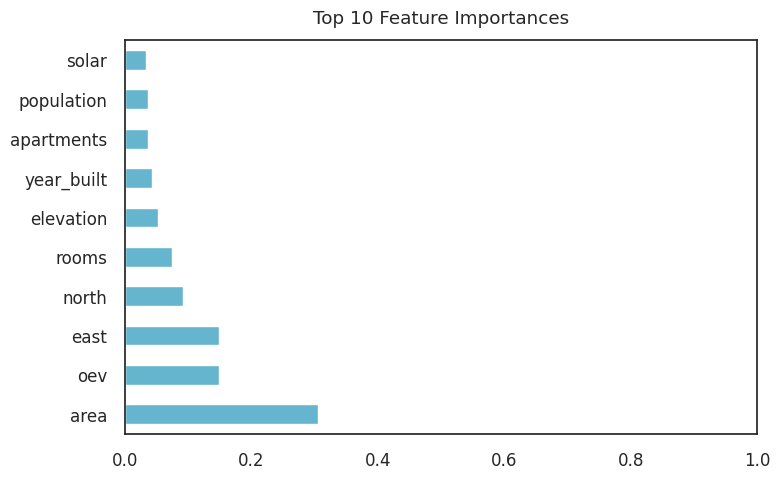

In [104]:
X_data_feature = train.drop(columns=['price'])
y_data_feature = train['price']

model = [XGBRegressor()]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY[0]   # deine Palette
    )

    plt.xlim(0, 1.0)
    plt.title("Top 10 Feature Importances")
    plt.tight_layout()
    plt.show()


# Train LightGBM Model and Analyze Feature Importances

> ➡️ *Here, we train a LightGBM regression model on the selected features and visualize the top feature importances to evaluate which variables contribute most to the price prediction.*


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000527 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 4535, number of used features: 11
[LightGBM] [Info] Start training from score 1815.761632
LGBMRegresso:
 [508 413 245 461  88 303 137 204 242 362  37]


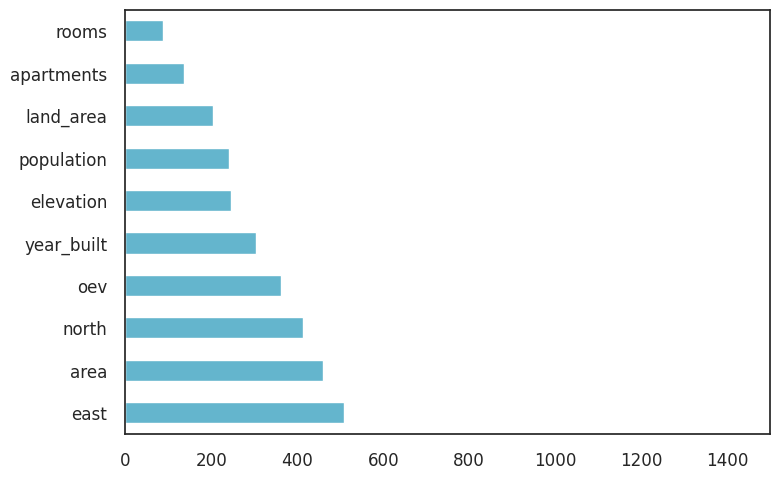

In [107]:
model = [LGBMRegressor()]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY[0]   # PRIMARY-Farbe
    )

    plt.xlim(0, 1500)
    plt.tight_layout()
    plt.show()


# Train CatBoost Model and Analyze Feature Importances

> ➡️ *Here, we train a CatBoost regression model on the selected features and visualize the top feature importances to assess which variables have the strongest influence on the price prediction.*


CatBoostRegr:
 [25.84986321 11.11569866  3.35672004 28.7392547   4.30500635  5.13945402
  2.66119794  2.88529428  3.27862969 11.61238471  1.0564964 ]


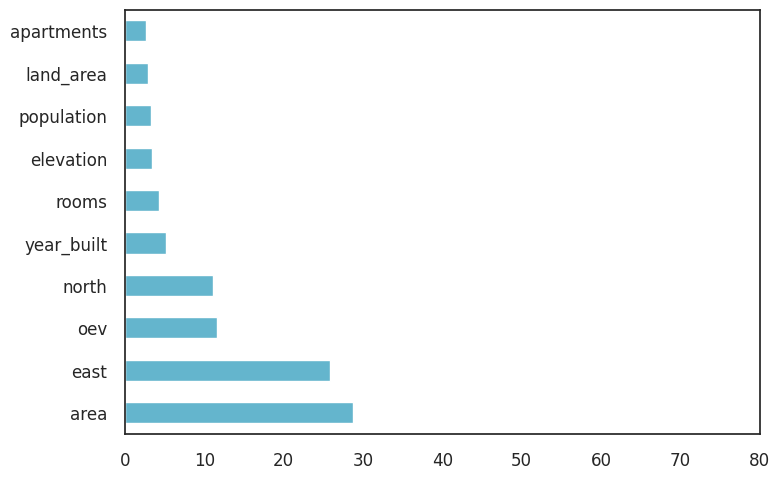

In [108]:
model = [CatBoostRegressor(logging_level='Silent')]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY[0]   # PRIMARY-Farbe
    )

    plt.xlim(0, 80)
    plt.tight_layout()
    plt.show()


# Pearson Correlation Analysis

> ➡️ *Here, we compute the Pearson correlation matrix for all numerical training features and visualize the relationships using a heatmap to identify linear dependencies and potential multicollinearity.*


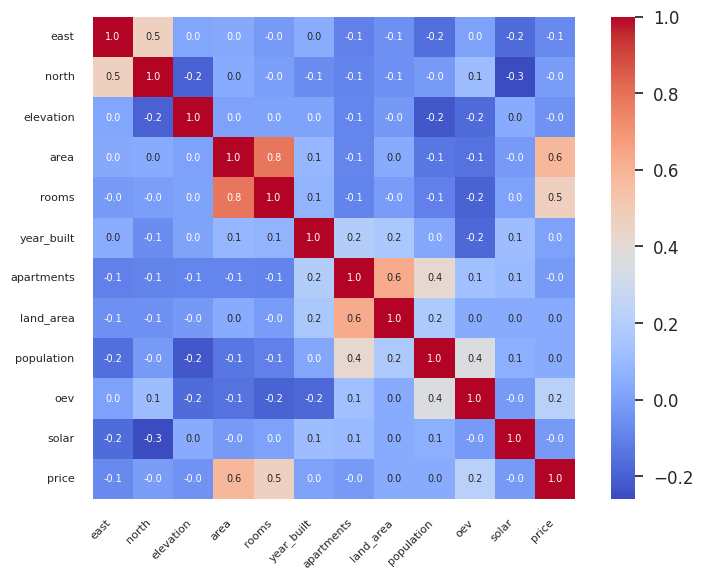

In [110]:
corr = train.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    cmap="coolwarm",      # statt "RdBu"
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7},
    square=True
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()


# Define Feature Matrix and Target Variable

> ➡️ *Here, we define the feature matrix by removing the target variable and several high‑correlation or low‑relevance attributes, while keeping the price column as the prediction target.*


In [38]:
drop_cols = [
    "price",
    "solar",
    "elevation",
    "year_built",
    "apartments",
    "east",
    "north"
]

X = train.drop(columns=drop_cols)

y = train["price"]

# Import Preprocessing Transformers

> ➡️ *Here, we import a collection of preprocessing transformers that can be used for scaling, normalization, power transformations, and encoding of numerical and categorical features.*


In [39]:
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler, MaxAbsScaler,QuantileTransformer
from sklearn.preprocessing import PowerTransformer,Normalizer,OrdinalEncoder,FunctionTransformer

# Standardize Feature Matrix

> ➡️ *Here, we scale the feature matrix using StandardScaler to normalize all numerical variables before model training.*


In [40]:
X_train=X
y_train=y

StandardScaler = StandardScaler()
X_train = StandardScaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train)
X_train

,0,1,2,3,4
0,0.986447,0.180795,0.076128,-0.510040,-0.644737
1,1.361977,-0.728192,0.148779,-0.921803,-0.578360
2,1.174212,1.089783,-0.078488,0.894799,0.271836
3,-0.703440,-0.728192,-0.044957,-1.018689,-0.019673
4,-1.204147,-1.637180,-0.138099,0.349818,-0.150755
...,...,...,...,...,...
4530,0.610917,1.089783,-0.207025,-0.594815,-0.651421
4531,-0.734734,-0.728192,-0.559103,-0.873360,-0.647745
4532,0.078915,-0.728192,-0.294579,-0.364712,-0.532772
4533,1.111624,0.180795,0.146917,-1.115574,-0.522277


# Train–Evaluation Split

> ➡️ *Here, we split the standardized feature matrix into training and evaluation subsets to validate model performance on unseen data.*


In [41]:
X_train, X_eval, y_train, y_eval = train_test_split(X_train, y_train, test_size=0.2,random_state=2019)
print("Shape of X_train: ",X_train.shape)
print("Shape of X_eval: ", X_eval.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_eval",y_eval.shape)

Shape of X_train:  (3628, 5)
Shape of X_eval:  (907, 5)
Shape of y_train:  (3628,)
Shape of y_eval (907,)


# Target Distribution Analysis

> ➡️ *Here, we visualize the distribution of the target variable in the training set and compute skewness and kurtosis to assess asymmetry and tail behavior.*


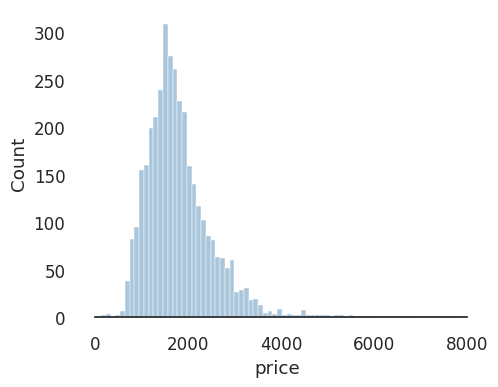

Skewness: 1.731715
Kurtosis: 6.533266


In [117]:
sns.set_style("white")
sns.set_color_codes(palette='deep')
f, ax = plt.subplots(figsize=(5, 4))
sns.histplot(y_train)
ax.xaxis.grid(False)

sns.despine(trim=True, left=True)
plt.show()

print("Skewness: %f" % y_train.skew())
print("Kurtosis: %f" % y_train.kurt())

# Target Variable Boxplot

> ➡️ *Here, we visualize the distribution of the target variable using a boxplot to detect outliers and assess the overall spread of price values.*


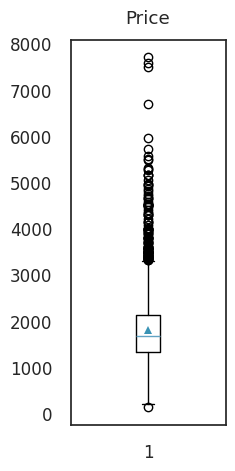

In [43]:
plt.figure(figsize=(2,5))
plt.boxplot(y_train,showmeans=True)
plt.title('Price')
plt.show()

# Optimized XGBoost Hyperparameters

> ➡️ *Here, we define the optimized XGBoost hyperparameters obtained from the tuning process to configure the final model setup.*


In [44]:
params_XGB_best ={'n_estimators': 2565,
 'learning_rate': 0.09732287808197748,
 'max_depth': 6,
 'min_child_weight': 0.007737991528812258,
 'subsample': 0.1,
 'colsample_bytree': 1.0,
 'colsample_bylevel': 0.9,
 'gamma': 1.3007598689577686,
 'reg_lambda': 9.683728618282095e-06,
 'reg_alpha': 0.08617584406570492}

# Optimized LightGBM Hyperparameters

> ➡️ *Here, we define the optimized LightGBM hyperparameters obtained from the tuning process to configure the final model setup.*


In [45]:
params_LGBM_best ={'n_estimators': 2309,
 'learning_rate': 0.04942932762026841,
 'max_depth': 6,
 'min_child_weight': 0.21030657642741743,
 'subsample': 0.30000000000000004,
 'colsample_bytree': 0.775,
 'reg_lambda': 0.21539132638034386,
 'reg_alpha': 2.5398950960373498e-08}

# Train Final XGBoost and LightGBM Models

> ➡️ *Here, we train the final XGBoost and LightGBM models using the optimized hyperparameters and fit them on the standardized training data.*


In [46]:
XGBRegressor_model = xgb.XGBRegressor(**params_XGB_best,objective='reg:absoluteerror').fit(X_train,y_train)
LGBM_model = lgbm.LGBMRegressor(**params_LGBM_best,objective='regression_l1').fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 928
[LightGBM] [Info] Number of data points in the train set: 3628, number of used features: 5
[LightGBM] [Info] Start training from score 1675.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

# Model Evaluation: Cross‑Validation and Evaluation Metrics

> ➡️ *Here, we evaluate both models using cross‑validation on the training set and compute R² and Median Absolute Error on the evaluation split to compare their predictive performance.*


In [47]:
cv_XGBoost = cross_val_score(estimator = XGBRegressor_model, X = X_train, y = y_train, cv = 5)
y_pred_XGBoost_eval = XGBRegressor_model.predict(X_eval)
r2_score_XGBoost_eval = r2_score(y_eval, y_pred_XGBoost_eval)
MedAE_XGBoost = (np.sqrt(median_absolute_error(y_eval, y_pred_XGBoost_eval)))
print("CV: ", cv_XGBoost.mean())
print('R2_score (eval): ', r2_score_XGBoost_eval)
print("MedAE: ", MedAE_XGBoost)

cv_LGBM = cross_val_score(estimator = LGBM_model, X = X_train, y = y_train, cv = 5)
y_pred_LGBM_eval = LGBM_model.predict(X_eval)
r2_score_LGBM_eval = r2_score(y_eval, y_pred_LGBM_eval)
MedAE_LGBM = (np.sqrt(median_absolute_error(y_eval, y_pred_LGBM_eval)))
print("CV: ", cv_LGBM.mean())
print('R2_score (eval): ', r2_score_LGBM_eval)
print("MedAE: ", MedAE_LGBM)

CV:  0.32912594079971313
R2_score (eval):  0.3325788974761963
MedAE:  16.802767861650057
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 2902, number of used features: 5
[LightGBM] [Info] Start training from score 1675.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

# Model Performance Comparison

> ➡️ *Here, we consolidate the evaluation metrics of both models into a comparison table to summarize their performance across Median Absolute Error, R² score, and cross‑validation results.*


In [48]:
models = [('XGB', MedAE_XGBoost,  r2_score_XGBoost_eval, cv_XGBoost.mean()),
        ( 'LGBM', MedAE_LGBM, r2_score_LGBM_eval, cv_LGBM.mean())
         ]


predict = pd.DataFrame(data = models, columns=['Model', 'MedAE', 'R2_Score(eval)', 'Cross-Validation'])
predict

,Model,MedAE,R2_Score(eval),Cross-Validation
0,XGB,16.802768,0.332579,0.329126
1,LGBM,15.555719,0.510206,0.473619


# Visualize Model Performance (MedAE)

> ➡️ *Here, we visualize the Median Absolute Error of each model using a horizontal bar plot to compare their validation performance side by side.*


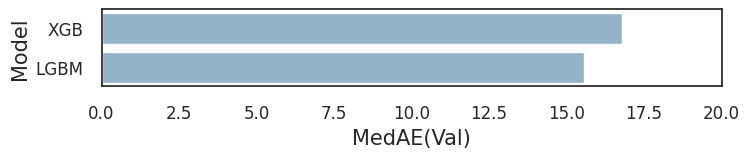

In [49]:
f, axe = plt.subplots(1,1, figsize=(8,1))

predict.sort_values(by=['MedAE'], ascending=False, inplace=True)

sns.barplot(x='MedAE', y='Model',  data = predict, ax = axe)
axe.set_xlabel('MedAE(Val)', size=15)
axe.set_ylabel('Model', size=15)
axe.set_xlim(0,20.0)
plt.show()

# Visualize Model Performance (R² Score)

> ➡️ *Here, we visualize the evaluation R² scores of both models using a horizontal bar plot to compare their explanatory power on the validation set.*


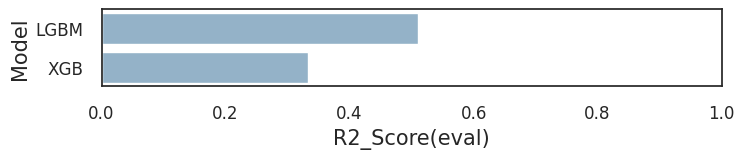

In [50]:
f, axe = plt.subplots(1,1, figsize=(8,1))

predict.sort_values(by=['R2_Score(eval)'], ascending=False, inplace=True)

sns.barplot(x='R2_Score(eval)', y='Model',  data = predict, ax = axe)
axe.set_xlabel('R2_Score(eval)', size=15)
axe.set_ylabel('Model', size=15)
axe.set_xlim(0,1.0)
plt.show()


# Visualize Model Performance (Cross‑Validation)

> ➡️ *Here, we visualize the mean cross‑validation scores of both models using a horizontal bar plot to compare their stability and generalization performance.*


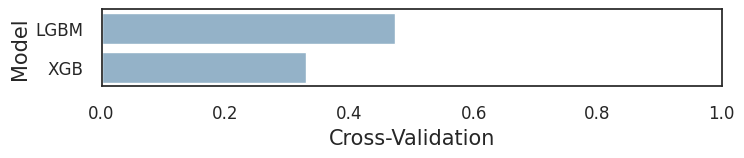

In [51]:
f, axe = plt.subplots(1,1, figsize=(8,1))

predict.sort_values(by=['Cross-Validation'], ascending=False, inplace=True)

sns.barplot(x='Cross-Validation', y='Model',  data = predict, ax = axe)
axe.set_xlabel('Cross-Validation', size=15)
axe.set_ylabel('Model', size=15)
axe.set_xlim(0,1.0)
plt.show()

# Prepare Test Dataset

> ➡️ *Here, we prepare the test dataset by resetting the index and removing the same non‑feature columns that were excluded from the training data to ensure consistent preprocessing.*


In [52]:
import_test0 = test.reset_index(drop=True)

import_test = import_test0.drop(
    columns=[
        'price',
        'solar_class',
        'elevation',
        'year_built',
        'number_of_apartments',
        'total_floor_area',
        'lv95_east',
        'lv95_north'
    ],
    errors='ignore'
)

import_test

,east,north,area,rooms,apartments,land_area,population,oev,solar
0,2539103.75,1152548.250,57,2,20,420.0,186,10892.0,3.0
1,2655301.50,1222483.375,48,2,5,409.0,58,73.0,3.0
2,2604730.00,1129117.875,70,2,16,297.0,29,126.0,4.0
3,2638795.25,1266197.000,94,3,9,267.0,144,3537.0,4.0
4,2613913.50,1210679.250,84,3,8,292.0,93,4172.0,4.0
...,...,...,...,...,...,...,...,...,...
903,2697976.50,1122567.375,54,2,2,105.0,37,297.0,4.0
904,2681588.00,1253222.125,80,2,6,247.0,79,2017.0,3.0
905,2605452.50,1210915.875,113,3,8,484.0,17,2174.0,1.0
906,2609938.75,1224044.250,90,3,8,312.0,81,5234.0,4.0


# Prepare Training Feature Matrix

> ➡️ *Here, we reset the index of the training feature matrix to ensure a clean, continuous index before applying further preprocessing or merging operations.*


In [53]:
import_train = X.reset_index(drop=True)
import_train

,area,rooms,land_area,population,oev
0,109,3,446.0,67,342.0
1,121,2,485.0,33,1335.0
2,115,4,363.0,183,14054.0
3,55,2,381.0,25,9693.0
4,39,1,331.0,138,7732.0
...,...,...,...,...,...
4530,97,4,294.0,60,242.0
4531,54,2,105.0,37,297.0
4532,80,2,247.0,79,2017.0
4533,113,3,484.0,17,2174.0


# Scale Combined Train–Test Features

> ➡️ *Here, we concatenate the training and test feature matrices to apply a consistent StandardScaler transformation across both datasets, and then extract the scaled test portion for final prediction.*


In [54]:
Row_Number = len(import_test)

X_test_target1_df = pd.concat([import_train, import_test], ignore_index=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_test_target1_scaled = scaler.fit_transform(X_test_target1_df)

test_pred_target0 = pd.DataFrame(
    X_test_target1_scaled,
    columns=X_test_target1_df.columns
).tail(Row_Number)

test_pred_target0

,area,rooms,land_area,population,oev,east,north,apartments,solar
4535,-0.644121,-0.741164,0.022991,0.918186,0.057047,-1.401520,-1.208310,0.165303,-0.084370
4536,-0.925212,-0.741164,0.002634,-0.620629,-0.666065,0.257295,0.101386,-0.457153,-0.084370
4537,-0.238101,-0.741164,-0.204643,-0.969266,-0.662523,-0.464653,-1.647097,-0.000686,0.897783
4538,0.511474,0.170922,-0.260163,0.413262,-0.434541,0.021655,0.920025,-0.291165,0.897783
4539,0.199151,0.170922,-0.213896,-0.199859,-0.392099,-0.333552,-0.119673,-0.332662,0.897783
...,...,...,...,...,...,...,...,...,...
5438,-0.737818,-0.741164,-0.559973,-0.873090,-0.651093,0.866515,-1.769770,-0.581644,0.897783
5439,0.074222,-0.741164,-0.297177,-0.368167,-0.536133,0.632556,0.677040,-0.415656,-0.084370
5440,1.104888,0.170922,0.141435,-1.113530,-0.525640,-0.454339,-0.115242,-0.332662,-2.048675
5441,0.386545,0.170922,-0.176882,-0.344123,-0.321118,-0.390294,0.130617,-0.332662,0.897783


# Finalize Scaled Test Features

> ➡️ *Here, we reset the index of the scaled test feature matrix to ensure a clean, continuous index before generating predictions.*


In [55]:
test_pred_target0 = test_pred_target0.reset_index(drop=True)
test_pred_target0

,area,rooms,land_area,population,oev,east,north,apartments,solar
0,-0.644121,-0.741164,0.022991,0.918186,0.057047,-1.401520,-1.208310,0.165303,-0.084370
1,-0.925212,-0.741164,0.002634,-0.620629,-0.666065,0.257295,0.101386,-0.457153,-0.084370
2,-0.238101,-0.741164,-0.204643,-0.969266,-0.662523,-0.464653,-1.647097,-0.000686,0.897783
3,0.511474,0.170922,-0.260163,0.413262,-0.434541,0.021655,0.920025,-0.291165,0.897783
4,0.199151,0.170922,-0.213896,-0.199859,-0.392099,-0.333552,-0.119673,-0.332662,0.897783
...,...,...,...,...,...,...,...,...,...
903,-0.737818,-0.741164,-0.559973,-0.873090,-0.651093,0.866515,-1.769770,-0.581644,0.897783
904,0.074222,-0.741164,-0.297177,-0.368167,-0.536133,0.632556,0.677040,-0.415656,-0.084370
905,1.104888,0.170922,0.141435,-1.113530,-0.525640,-0.454339,-0.115242,-0.332662,-2.048675
906,0.386545,0.170922,-0.176882,-0.344123,-0.321118,-0.390294,0.130617,-0.332662,0.897783


# Generate Test Predictions (XGBoost & LightGBM)

> ➡️ *Here, we generate predictions for the scaled test dataset using both trained models and convert the outputs into labeled DataFrames for further processing or ensemble methods.*


In [56]:
predict_XGB = XGBRegressor_model.predict(test_pred_target0)
predict_LGBM = LGBM_model.predict(test_pred_target0)

predict_XGB_df=pd.DataFrame(predict_XGB)
predict_LGBM_df=pd.DataFrame(predict_LGBM)

predict_XGB_df=predict_XGB_df.set_axis(axis=1,labels=['XGB_pred'])
predict_LGBM_df=predict_LGBM_df.set_axis(axis=1,labels=['LGBM_pred'])

display(predict_XGB_df.head())
display(predict_LGBM_df.head())

ValueError: feature_names mismatch: ['0', '1', '2', '3', '4'] ['area', 'rooms', 'land_area', 'population', 'oev', 'east', 'north', 'apartments', 'solar']
expected 3, 2, 1, 0, 4 in input data
training data did not have the following fields: solar, population, land_area, area, apartments, north, oev, rooms, east